In [13]:
# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

SERVER = "DESKTOP-LKG2222"
DATABASE = "FashionEcommerce"
engine = create_engine(
    f"mssql+pyodbc://{SERVER}/{DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
    "&TrustServerCertificate=yes"
)

df = pd.read_sql("SELECT * FROM warehouse.Churn_Features_V2", engine)
print(df.shape)
df.head()

(1211337, 13)


,Customer_Key,Recency_Days,Tenure_Days,Frequency,Monetary_USD,Avg_Line_Value_USD,Discount_Usage_Rate,Distinct_Categories,Total_Units,Churned,Orders_Last_90d,Orders_Prior_90d,Momentum
0,953644,342,490,4,227.965,45.593000,0.600000,3,5,1,0,0,0
1,1055504,127,351,2,149.225,37.306250,0.000000,2,4,1,0,1,-1
2,243927,143,640,4,283.480,47.246667,0.333333,2,6,1,0,1,-1
3,1138363,202,420,2,165.078,55.026000,0.666667,2,4,1,0,0,0
4,46854,98,700,4,213.400,53.350000,0.500000,3,6,0,0,1,-1


In [14]:
# ── Features / target ──
feature_cols = [
    "Recency_Days", "Tenure_Days", "Frequency", "Monetary_USD",
    "Avg_Line_Value_USD", "Discount_Usage_Rate", "Distinct_Categories", "Total_Units",
    "Orders_Last_90d", "Orders_Prior_90d", "Momentum"
]

X = df[feature_cols]
y = df["Churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# ── Entraînement des 3 modèles ──
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
    predictions[name] = (y_pred, y_proba)
    print(f"{name} entraîné.")

results_df = pd.DataFrame(results).T.round(4)
results_df

Logistic Regression entraîné.
Random Forest entraîné.
Gradient Boosting entraîné.


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.6596,0.6675,0.9175,0.7728,0.6397
Random Forest,0.6594,0.6693,0.9094,0.7711,0.6398
Gradient Boosting,0.6596,0.6691,0.9109,0.7715,0.6402


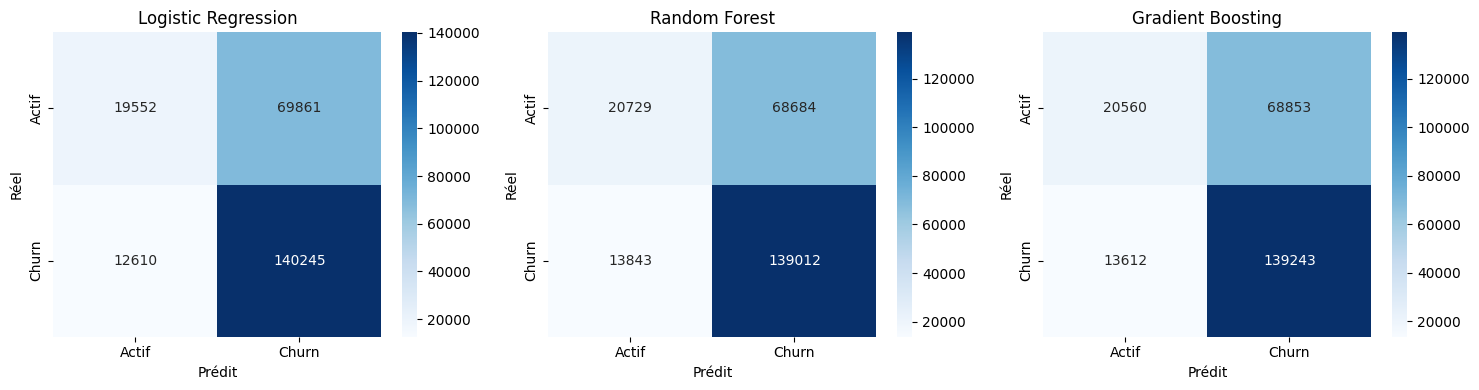

In [16]:
# ── Matrices de confusion ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (y_pred, _)) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Actif", "Churn"], yticklabels=["Actif", "Churn"])
    ax.set_title(name)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.tight_layout()
plt.show()

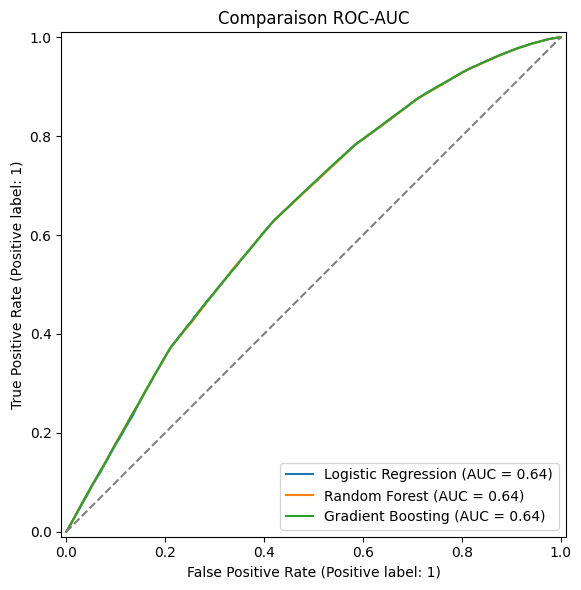

In [17]:
# ── Courbes ROC comparées ──
fig, ax = plt.subplots(figsize=(7, 6))

for name, (_, y_proba) in predictions.items():
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_title("Comparaison ROC-AUC")
plt.tight_layout()
plt.show()

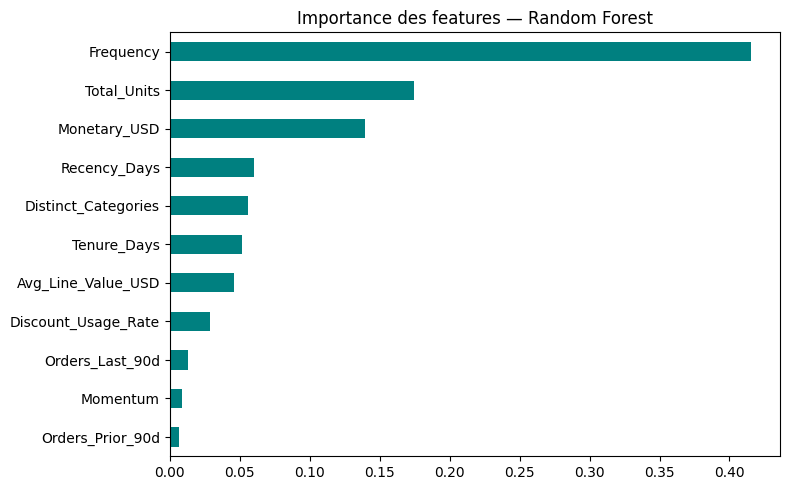

In [18]:
# ── Feature importance (meilleur modèle non-linéaire) ──
best_tree_model = models["Random Forest"]  # ou "Gradient Boosting" selon le meilleur ROC-AUC

importances = pd.Series(best_tree_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="teal")
ax.set_title("Importance des features — Random Forest")
plt.tight_layout()
plt.show()

In [19]:
# ── Sauvegarde des prédictions vers SQL Server (pour Power BI / ciblage marketing) ──
best_model_name = results_df["ROC-AUC"].idxmax()
print(f"Meilleur modèle: {best_model_name}")

best_model = models[best_model_name]
if best_model_name == "Logistic Regression":
    df["Churn_Probability"] = best_model.predict_proba(scaler.transform(X))[:, 1]
else:
    df["Churn_Probability"] = best_model.predict_proba(X)[:, 1]

churn_export = df[["Customer_Key", "Churned", "Churn_Probability"] + feature_cols]
churn_export.to_sql(
    "Customer_Churn_Predictions",
    engine,
    schema="warehouse",
    if_exists="replace",
    index=False,
    chunksize=5000
)
print(f"{len(churn_export)} clients scorés exportés vers warehouse.Customer_Churn_Predictions")

Meilleur modèle: Gradient Boosting
1211337 clients scorés exportés vers warehouse.Customer_Churn_Predictions


In [20]:
# ── Vérité qui pique : comparaison à la baseline naïve ──
naive_pred = np.ones(len(y_test))  # prédit "Churn" pour tout le monde

print("Baseline naïve (toujours prédire Churn):")
print(f"  Accuracy:  {accuracy_score(y_test, naive_pred):.4f}")
print(f"  Precision: {precision_score(y_test, naive_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, naive_pred):.4f}")
print(f"  F1:        {f1_score(y_test, naive_pred):.4f}")

Baseline naïve (toujours prédire Churn):
  Accuracy:  0.6309
  Precision: 0.6309
  Recall:    1.0000
  F1:        0.7737
